In [ ]:
import os
import cv2
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from PIL import Image, ImageOps, ImageEnhance, ImageFilter
# Configuration

# device configuration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Apprentissage sur : {device}")

# ==========================================
# CONFIGURATION GLOBALE
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 5

# 1. Choix des lieux (Mettre en commentaire ceux qu'on ne veut pas)
# Si tu veux tout, mets ['Aire', 'Ziplo']
# LIEUX_A_GARDER = ['Aire', 'Ziplo']
LIEUX_A_GARDER = {'Aire'}     # Mapping des lieux vers des labels numériques 

# 2. Unification des classes (Mapping)
# Par défaut (Multi-classes) : {0:0, 1:1, 2:2, 3:3, 4:4}
# Binaire (Eau propre vs Pollution) : {0:0, 1:1, 2:1, 3:1, 4:1}
# Regrouper Mousse et Irisation : {0:0, 1:1, 2:2, 3:3, 4:3}
MAPPING_CLASSES = {0:0, 1:1, 2:2, 3:1, 4:4}

# 3. Choix des classes à entraîner (après le mapping)
# Si tu ne veux entraîner que sur propre(0) et huile(4-> mapped to 1), tu mets [0, 1]
# CLASSES_A_GARDER = [0, 1, 2, 3, 4]
CLASSES_A_GARDER = [0, 2, 4] 


Apprentissage sur : mps


Total initial d'images : 4203
Images après filtrage des lieux ({'Aire'}) : 1599
Images après filtrage des classes ([0, 4]) : 1554

Répartition finale par classe pour l'entraînement :
Classe
4    1005
0     549
Name: count, dtype: int64


/var/folders/65/_6_vzrxd7ql89tvbx49tn3rr0000gn/T/ipykernel_95153/642761984.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Classe', palette='viridis')


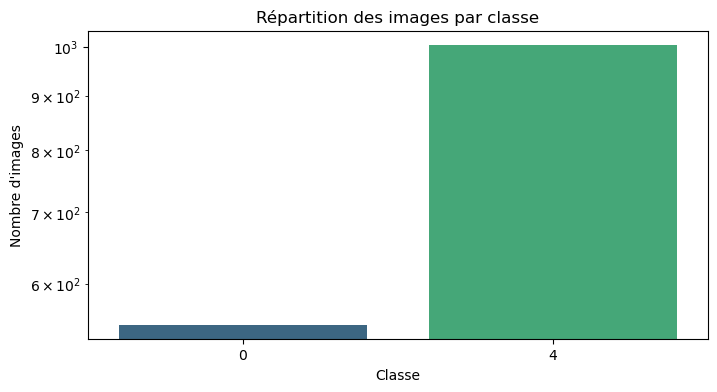

In [3]:
# Chargement du dataset 
csv_file = 'dataset_complet.csv' 
df = pd.read_csv(csv_file)

print(f"Total initial d'images : {len(df)}")

# --- 1. FILTRAGE PAR LIEU ---
pattern_lieux = '|'.join(LIEUX_A_GARDER)
df = df[df['Nom_Image'].str.contains(pattern_lieux, case=False, na=False)]
print(f"Images après filtrage des lieux ({LIEUX_A_GARDER}) : {len(df)}")

# --- 2. UNIFICATION DES CLASSES (MAPPING) ---
# Sécurité : on force la colonne en entier (au cas où ce soit du texte '0')
df['Classe'] = df['Classe'].fillna(-1).astype(int) 
df['Classe'] = df['Classe'].map(MAPPING_CLASSES)

# --- 3. FILTRAGE DES CLASSES ---
df = df[df['Classe'].isin(CLASSES_A_GARDER)]
df = df.dropna(subset=['Classe']) # Sécurité
df['Classe'] = df['Classe'].astype(int)

print(f"Images après filtrage des classes ({CLASSES_A_GARDER}) : {len(df)}")

# Affichage des infos
print("\nRépartition finale par classe pour l'entraînement :")
print(df['Classe'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Classe', palette='viridis')
plt.title("Répartition des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.yscale('log')
plt.show()



In [77]:
# Dossier source 
SOURCE_DIR = 'data' 
TARGET_DIR = 'dataset'

# SECURITE : On vide le dossier dataset s'il existe pour éviter les conflits avec un ancien entraînement
if os.path.exists(TARGET_DIR):
    shutil.rmtree(TARGET_DIR, ignore_errors=True)

# Filtrage des classes "fantômes" (qui n'ont qu'une seule image)
class_counts = df['Classe'].value_counts()
classes_to_keep = class_counts[class_counts > 1].index
df_clean = df[df['Classe'].isin(classes_to_keep)]
print(f"Images conservées après nettoyage des classes rares : {len(df_clean)} / {len(df)}")

# Train / Validation (80% / 20%)
train_df, val_df = train_test_split(df_clean, test_size=0.2, random_state=42, stratify=df_clean['Classe'])

print(f"Taille du jeu d'entraînement : {len(train_df)}")
print(f"Taille du jeu de validation : {len(val_df)}")

def copy_images(dataframe, split_name):
    print(f"\nCopie des images pour le set : {split_name}...")
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        img_name = row['Nom_Image']
        img_class = str(row['Classe']) 
        
        dest_dir = os.path.join(TARGET_DIR, split_name, img_class)
        os.makedirs(dest_dir, exist_ok=True)
        
        src_path = os.path.join(SOURCE_DIR, img_name)
        dest_path = os.path.join(dest_dir, img_name)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dest_path)

copy_images(train_df, 'train')
copy_images(val_df, 'val')
print("\nArborescence prête !")



Images conservées après nettoyage des classes rares : 1554 / 1554
Taille du jeu d'entraînement : 1243
Taille du jeu de validation : 311

Copie des images pour le set : train...


100%|██████████| 1243/1243 [00:03<00:00, 350.50it/s]



Copie des images pour le set : val...


100%|██████████| 311/311 [00:00<00:00, 463.68it/s]


Arborescence prête !


In [34]:
def balance_and_augment_dataset(train_dir):
    print("Début de l'équilibrage intelligent et de la Data Augmentation...")
    
    # 1. Lister les classes et compter les images
    classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
    class_counts = {}
    class_files = {}
    
    for cls in classes:
        class_dir = os.path.join(train_dir, cls)
        # On ne sélectionne que les vraies images
        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
        class_files[cls] = files
        class_counts[cls] = len(files)
        
    print(f"Répartition initiale : {class_counts}")
    
    # 2. Trouver la classe de pollution la plus grande (Objectif)
    minority_classes = [c for c in classes if c != '0']
    
    if not minority_classes:
        print("Aucune classe de pollution trouvée. Arrêt.")
        return
        
    target_size = max([class_counts[c] for c in minority_classes])
    
    if target_size == 0:
        print("Les classes de pollution sont vides. Arrêt.")
        return
        
    print(f"-> La plus grande classe de pollution contient {target_size} images.")
    print(f"-> Objectif : Aligner toutes les classes sur {target_size} images.\\n")
    
    # 3. DIMINUER la classe 0 (Sous-échantillonnage aléatoire)
    if '0' in classes and class_counts['0'] > target_size:
        print(f"📉 Réduction de la classe 0 (de {class_counts['0']} à {target_size} images)...")
        files_0 = class_files['0']
        random.shuffle(files_0) # Mélange aléatoire
        
        # On garde les "target_size" premiers, on supprime le reste
        files_to_delete = files_0[target_size:]
        for f in files_to_delete:
            os.remove(os.path.join(train_dir, '0', f))
        print(f"   {len(files_to_delete)} images d'eau propre ont été ignorées pour l'entraînement.")
    
    # 4. AUGMENTER les autres classes (Sur-échantillonnage)
    # Liste des transformations utiles pour la pollution de l'eau
    augmentations = [
        lambda img: ImageOps.mirror(img),                                          # Miroir horizontal
        lambda img: img.rotate(random.uniform(-15, 15), fillcolor=(128, 128, 128)),# Rotation légère (-15° à 15°)
        lambda img: ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3)),# Météo (plus sombre ou plus clair)
        lambda img: ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3)),  # Fait ressortir la texture
        lambda img: ImageEnhance.Color(img).enhance(random.uniform(0.5, 1.5)),     # Saturation (utile pour l'irisation)
        lambda img: img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.2))) # Flou de mouvement de l'eau
    ]
    
    for cls in minority_classes:
        current_count = class_counts[cls]
        needed = target_size - current_count
        
        if needed <= 0:
            print(f"✅ Classe {cls} : Déjà à {current_count} images (Pas d'augmentation).")
            continue
            
        print(f"📈 Classe {cls} : Création de {needed} images manquantes...")
        class_dir = os.path.join(train_dir, cls)
        original_files = class_files[cls]
        
        generated_count = 0
        file_idx = 0
        
        with tqdm(total=needed, desc=f"Augmentation {cls}") as pbar:
            while generated_count < needed:
                # On tourne en boucle sur les images originales
                original_file = original_files[file_idx % len(original_files)]
                filepath = os.path.join(class_dir, original_file)
                
                try:
                    img = Image.open(filepath)
                    
                    # On choisit UNE transformation totalement au hasard dans notre liste
                    transfo = random.choice(augmentations)
                    img_aug = transfo(img)
                    
                    # Créer un nom unique : nom_original_aug_1.jpg
                    name, ext = os.path.splitext(original_file)
                    new_filename = f"{name}_aug_{generated_count}{ext}"
                    img_aug.save(os.path.join(class_dir, new_filename))
                    
                    generated_count += 1
                    pbar.update(1)
                except Exception as e:
                    pass
                    
                file_idx += 1

# Lancement de la fonction sur le dossier d'entraînement
balance_and_augment_dataset('dataset/train')

Début de l'équilibrage intelligent et de la Data Augmentation...
Répartition initiale : {'0': 2247, '1': 100, '4': 804, '2': 95}
-> La plus grande classe de pollution contient 804 images.
-> Objectif : Aligner toutes les classes sur 804 images.\n
📉 Réduction de la classe 0 (de 2247 à 804 images)...
   1443 images d'eau propre ont été ignorées pour l'entraînement.
📈 Classe 1 : Création de 704 images manquantes...


Augmentation 1: 100%|██████████| 704/704 [02:23<00:00,  4.90it/s]


✅ Classe 4 : Déjà à 804 images (Pas d'augmentation).
📈 Classe 2 : Création de 709 images manquantes...


Augmentation 2: 100%|██████████| 709/709 [02:18<00:00,  5.13it/s]


In [45]:
class EnhanceIridescenceCLAHE:
    """
    Filtre sur-mesure pour détecter l'huile/irisation :
    1. Applique le CLAHE sur la luminosité pour révéler la texture de l'eau.
    2. Multiplie la Saturation pour rendre les taches arc-en-ciel 'fluo'.
    """
    def __init__(self, clip_limit=3.0, tile_grid_size=(8, 8), saturation_scale=2.5):
        # Initialisation de l'algorithme CLAHE d'OpenCV
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        self.saturation_scale = saturation_scale

    def __call__(self, img):
        # 1. Convertir l'image PIL en tableau Numpy (Format RGB)
        img_np = np.array(img)
        
        # 2. Convertir en espace HSV
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV).astype(np.float32)
        
        # 3. Extraire et appliquer CLAHE sur la couche 'V' (Luminosité)
        v_channel = hsv[:, :, 2].astype(np.uint8)
        hsv[:, :, 2] = self.clahe.apply(v_channel)
        
        # 4. Booster violemment la couche 'S' (Saturation)
        # Les couleurs irisées vont exploser visuellement
        hsv[:, :, 1] = hsv[:, :, 1] * self.saturation_scale
        hsv[:, :, 1] = np.clip(hsv[:, :, 1], 0, 255) # Sécurité pour ne pas dépasser la valeur max
        
        # 5. Reconvertir en RGB pour le réseau de neurones
        hsv = hsv.astype(np.uint8)
        img_enhanced = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        
        return Image.fromarray(img_enhanced)

# --- TRANSFORMATIONS (AVEC CLAHE & BOOST COULEURS) ---
train_transforms = transforms.Compose([
    EnhanceIridescenceCLAHE(clip_limit=3.0, saturation_scale=2.5), # <--- LE RÉVÉLATEUR
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_transforms = transforms.Compose([
    EnhanceIridescenceCLAHE(clip_limit=3.0, saturation_scale=2.5), # <--- LE RÉVÉLATEUR
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('dataset/data_masked/train', transform=train_transforms)
val_dataset = datasets.ImageFolder('dataset/data_masked/val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

NUM_CLASSES = len(train_dataset.classes)

In [46]:
import torch.nn as nn
import torch.nn.functional as F

class SimplePollutionCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimplePollutionCNN, self).__init__()
        
        # 1ère couche : Cherche les couleurs basiques (RGB)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        # 2ème couche : Cherche les petites textures (brillance)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # 3ème couche : Combine les textures pour repérer la nappe d'huile
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Outil de réduction de taille
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Couches de décision finale (64 filtres * 28px * 28px)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5) # Empêche d'apprendre par coeur !
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Passage dans les filtres d'analyse
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Aplatissement pour la décision
        x = x.view(-1, 64 * 28 * 28)
        
        # Prise de décision
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- INITIALISATION ---
# On utilise notre nouveau modèle !
model = SimplePollutionCNN(num_classes=NUM_CLASSES).to(device)

# On entraîne TOUT le modèle (contrairement à MobileNet où on gelait des couches)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Calcul des poids pour les classes déséquilibrées
train_labels = [label for _, label in train_dataset.samples]
classes_unique = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=train_labels)
weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

print("Modèle SimplePollutionCNN initialisé !")

Modèle SimplePollutionCNN initialisé !


In [47]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train() # Passe le modèle en mode entraînement
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() # Réinitialiser les gradients
        
        outputs = model(inputs) # Propagation avant (Forward)
        loss = criterion(outputs, labels) # Calcul de l'erreur
        
        loss.backward() # Rétropropagation (Backward)
        optimizer.step() # Mise à jour des poids
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # --- PHASE DE VALIDATION ---
    model.eval() # Passe le modèle en mode évaluation (désactive le Dropout par ex)
    val_loss = 0.0
    correct = 0
    
    with torch.no_grad(): # On ne calcule pas les gradients pour la validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    epoch_acc = correct.float() / len(val_dataset)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_acc:.4f}")

Epoch 1/5 - Train Loss: 0.8435 - Val Loss: 0.6099 - Val Acc: 0.6784
Epoch 2/5 - Train Loss: 0.5230 - Val Loss: 0.2722 - Val Acc: 0.9095
Epoch 3/5 - Train Loss: 0.2573 - Val Loss: 0.1339 - Val Acc: 0.9497
Epoch 4/5 - Train Loss: 0.1375 - Val Loss: 0.0674 - Val Acc: 0.9648
Epoch 5/5 - Train Loss: 0.0670 - Val Loss: 0.0427 - Val Acc: 0.9799


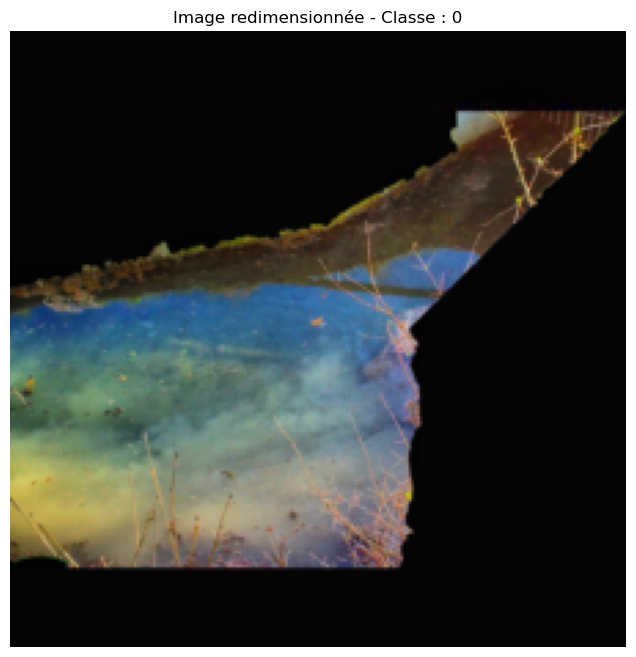

Format du tenseur envoyé au modèle : torch.Size([3, 224, 224])


In [48]:
import matplotlib.pyplot as plt
import numpy as np

# On "pioche" un seul batch (paquet de 32 images) dans notre DataLoader
inputs, labels = next(iter(train_loader))

# On isole la toute première image et sa classe
img_tensor = inputs[0]
label_idx = labels[0].item()
class_name = train_dataset.classes[label_idx]

# PyTorch stocke en format (Canaux, Hauteur, Largeur) soit (3, 384, 384)
# Matplotlib a besoin du format (Hauteur, Largeur, Canaux) soit (384, 384, 3)
img_numpy = img_tensor.permute(1, 2, 0).numpy()

# Dé-normalisation (On fait l'inverse de la transformation PyTorch)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_unnormalized = std * img_numpy + mean

# On s'assure que les valeurs restent bien bloquées entre 0 et 1 pour l'affichage
img_ready = np.clip(img_unnormalized, 0, 1)

# Affichage !
plt.figure(figsize=(8, 8))
plt.imshow(img_ready)
plt.title(f"Image redimensionnée - Classe : {class_name}")
plt.axis('off') # On enlève les axes gradués
plt.show()

print(f"Format du tenseur envoyé au modèle : {img_tensor.shape}")

Rapport de Classification :

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       110
           4       1.00      0.96      0.98        89

    accuracy                           0.98       199
   macro avg       0.98      0.98      0.98       199
weighted avg       0.98      0.98      0.98       199



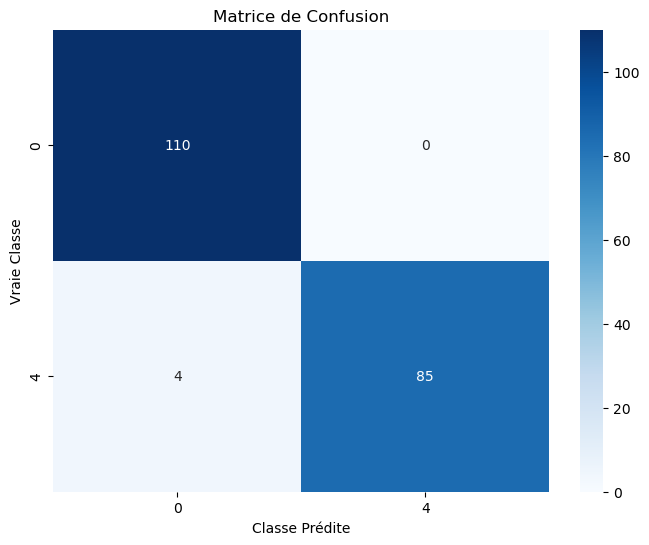

In [49]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = train_dataset.classes

# Rapport de classification (inclut le F1-Score)
print("Rapport de Classification :\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.title('Matrice de Confusion')
plt.show()

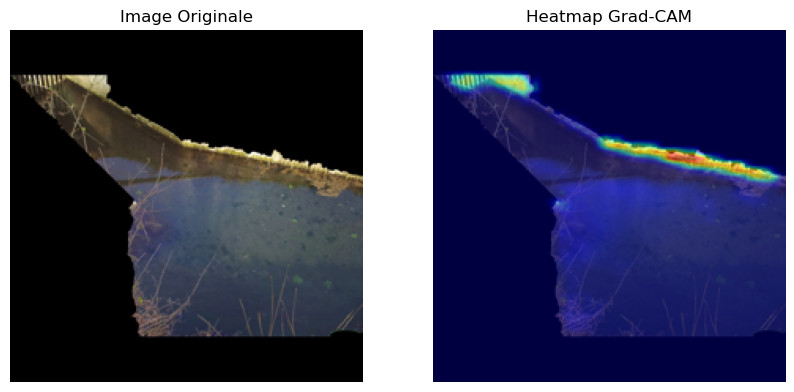

In [ ]:
# --- CORRECTION ICI : On dégèle le modèle pour permettre à Grad-CAM de calculer ses dérivées ---
for param in model.parameters():
    param.requires_grad = True
# ---------------------------------------------------------------------------------------------

# indique à Grad-CAM quelle est la dernière couche de convolution du modèle
# Pour MobileNetV2, c'est 'features[-1]'
target_layers = target_layers = [model.conv3]

# initialise Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

def display_heatmap(img_path, model, cam_explainer):
    # Chargement et préparation de l'image
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((IMG_SIZE, IMG_SIZE)) 
    
    # Transformation PyTorch
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(img_resized).unsqueeze(0).to(device) # Ajout de la dimension batch
    
    # Génération de la Heatmap
    model.eval()
    grayscale_cam = cam_explainer(input_tensor=input_tensor)[0, :]
    
    # image originale 
    img_float = np.float32(img_resized) / 255
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)
    
    # Affichage
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("Image Originale")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Heatmap Grad-CAM")
    plt.axis('off')
    plt.show()

# Teste avec une image de pollution de ton dataset de validation
image_test_path = 'dataset/data_masked/val/4/25032021_180000_RCNX0945_Aire.jpg' 
display_heatmap(image_test_path, model, cam)